# 06 — Validation

Post-optimization validation of top designs:
1. Re-evaluate with full VLM (no surrogate)
2. Full alpha polar
3. Surrogate vs VLM error analysis
4. Stability verification
5. Propulsion balance at multiple speeds
6. Cross-check vs v1 best design

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.parameterization.design_variables import BWBParams, params_from_vector
from src.parameterization.bwb_aircraft import build_airplane, compute_wing_area
from src.aero.evaluator import AeroEvaluator
from src.aero.mission import MissionCondition
from src.propulsion.edf_model import EDF_70MM, thrust_at_speed, endurance as compute_endurance

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [ ]:
%load_ext autoreload
%autoreload 2

## 1. Load Best Design

In [2]:
try:
    best_x = np.load('../output/best_x.npy')
    best_params = params_from_vector(best_x)
    print('Loaded optimized design from output/best_x.npy')
except FileNotFoundError:
    print('No optimized design found — using default params')
    best_params = BWBParams()

mission = MissionCondition()
evaluator = AeroEvaluator(mission)

Loaded optimized design from output/best_x.npy


## 2. Full VLM Re-evaluation

In [3]:
result = evaluator.evaluate(best_params)

print('═══ Full VLM Evaluation ═══')
for key in ['L_over_D', 'CL', 'CD', 'CD0_wing', 'CD0_body', 'CDi', 'CM',
            'alpha_eq', 'static_margin', 'Cn_beta', 'AR', 'S_ref',
            'struct_mass', 'internal_volume',
            'T_over_D', 'P_elec', 'endurance_min', 'range_km', 'duct_fits',
            'is_feasible', 'penalty']:
    val = result.get(key, 'N/A')
    if isinstance(val, float):
        print(f'  {key:20s} = {val:.4f}')
    else:
        print(f'  {key:20s} = {val}')

═══ Full VLM Evaluation ═══
  L_over_D             = 22.8737
  CL                   = 0.4142
  CD                   = 0.0181
  CD0_wing             = 0.0042
  CD0_body             = 0.0054
  CDi                  = 0.0085
  CM                   = -0.1721
  alpha_eq             = -2.0000
  static_margin        = 0.0900
  Cn_beta              = 0.4497
  AR                   = 8.0184
  S_ref                = 0.4976
  struct_mass          = 0.8253
  internal_volume      = 0.0021
  T_over_D             = 1.5682
  P_elec               = 116.9114
  endurance_min        = 8.0061
  range_km             = 9.6073
  duct_fits            = True
  is_feasible          = True
  penalty              = 0.0000


## 3. Alpha Polar

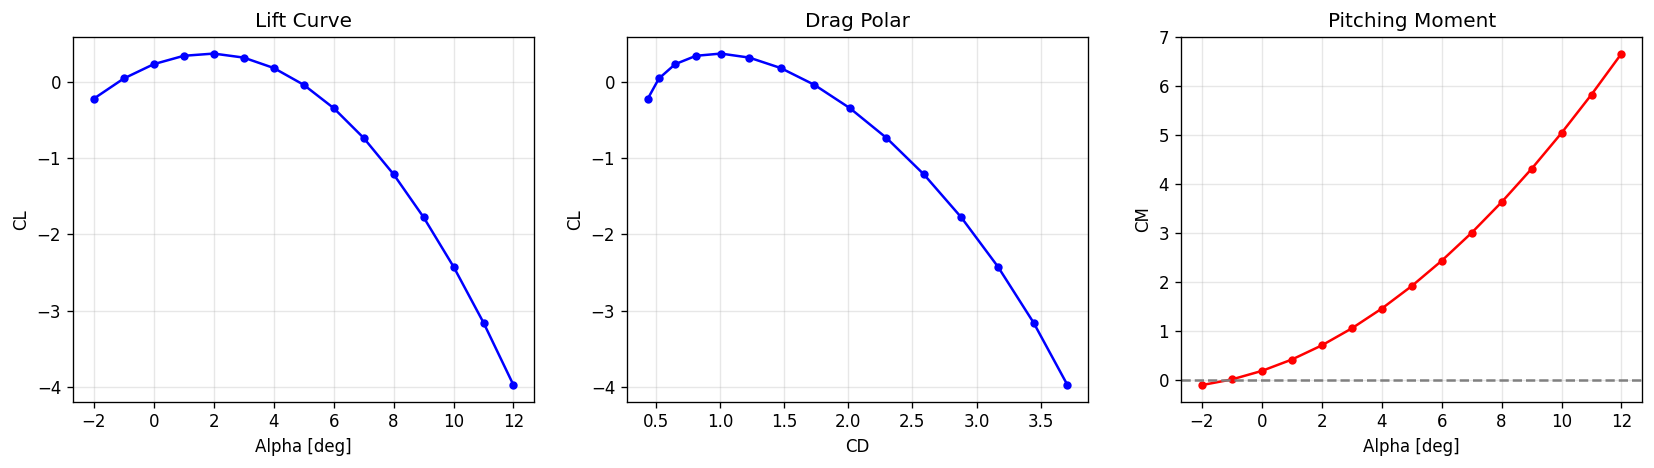

In [4]:
airplane = build_airplane(best_params)
import aerosandbox as asb

alphas = np.linspace(-2, 12, 15)
cls, cds, cms = [], [], []

for alpha in alphas:
    op = asb.OperatingPoint(
        atmosphere=mission.atmosphere,
        velocity=mission.velocity,
        alpha=alpha,
    )
    vlm = asb.VortexLatticeMethod(airplane=airplane, op_point=op,
                                   chordwise_resolution=4, spanwise_resolution=10)
    aero = vlm.run()
    cls.append(aero['CL'])
    cds.append(aero['CD'])
    cms.append(aero['Cm'])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(alphas, cls, 'b-o', ms=4)
axes[0].set_xlabel('Alpha [deg]')
axes[0].set_ylabel('CL')
axes[0].set_title('Lift Curve')
axes[0].grid(True, alpha=0.3)

axes[1].plot(cds, cls, 'b-o', ms=4)
axes[1].set_xlabel('CD')
axes[1].set_ylabel('CL')
axes[1].set_title('Drag Polar')
axes[1].grid(True, alpha=0.3)

axes[2].plot(alphas, cms, 'r-o', ms=4)
axes[2].set_xlabel('Alpha [deg]')
axes[2].set_ylabel('CM')
axes[2].set_title('Pitching Moment')
axes[2].axhline(0, color='gray', ls='--')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Propulsion Balance vs Speed

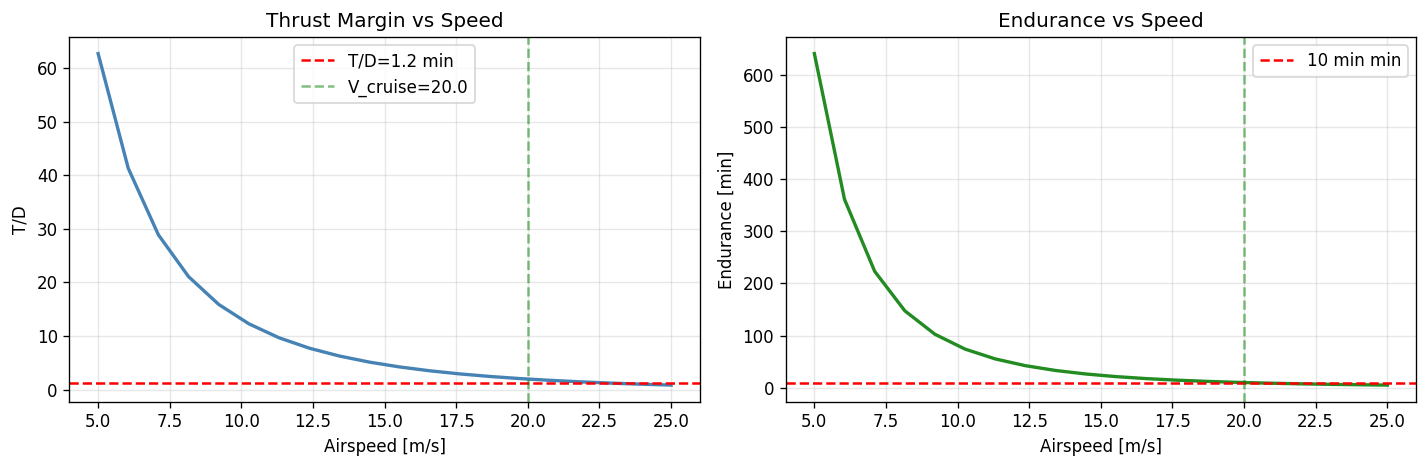

In [5]:
speeds = np.linspace(5, 25, 20)
s_ref = compute_wing_area(best_params)
td_ratios = []
endurances = []

for v in speeds:
    q = 0.5 * mission.density * v**2
    cl_req = mission.weight / (q * s_ref)
    cd_approx = result['CD']  # simplified: use same CD
    drag = cd_approx * q * s_ref
    t_avail = thrust_at_speed(EDF_70MM, v)
    td_ratios.append(t_avail / drag if drag > 0 else 0)
    e = compute_endurance(drag, v, EDF_70MM, mission.battery)
    endurances.append(e['endurance_min'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(speeds, td_ratios, 'steelblue', lw=2)
axes[0].axhline(1.2, color='red', ls='--', label='T/D=1.2 min')
axes[0].axvline(mission.velocity, color='green', ls='--', alpha=0.5, label=f'V_cruise={mission.velocity}')
axes[0].set_xlabel('Airspeed [m/s]')
axes[0].set_ylabel('T/D')
axes[0].set_title('Thrust Margin vs Speed')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(speeds, endurances, 'forestgreen', lw=2)
axes[1].axhline(10, color='red', ls='--', label='10 min min')
axes[1].axvline(mission.velocity, color='green', ls='--', alpha=0.5)
axes[1].set_xlabel('Airspeed [m/s]')
axes[1].set_ylabel('Endurance [min]')
axes[1].set_title('Endurance vs Speed')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()